DATA ACQUISITION
✓ EURUSD loaded | 2121 rows | 2018-01-01 -> 2026-02-16
✓ GBPUSD loaded | 2121 rows | 2018-01-01 -> 2026-02-16
✓ USDJPY loaded | 2121 rows | 2018-01-01 -> 2026-02-16
✓ EURJPY loaded | 2121 rows | 2018-01-01 -> 2026-02-16
✓ USDCHF loaded | 2121 rows | 2018-01-01 -> 2026-02-16

Aligned dataset summary:
Number of pairs : 5
Number of rows  : 2121
Date range      : 2018-01-01 -> 2026-02-16

DATA UNDERSTANDING

Descriptive statistics on close prices:
          EURUSD     GBPUSD     USDJPY     EURJPY     USDCHF
count  2121.0000  2121.0000  2121.0000  2121.0000  2121.0000
mean      1.1224     1.2945   126.6113   141.5439     0.9212
std       0.0563     0.0608    19.0510    18.6362     0.0586
min       0.9594     1.0672   102.4330   114.5040     0.7610
25%       1.0836     1.2541   109.2120   126.3210     0.8897
50%       1.1205     1.2937   114.9970   133.2240     0.9198
75%       1.1668     1.3404   146.4900   159.4800     0.9728
max       1.2505     1.4337   161.5700   186.18

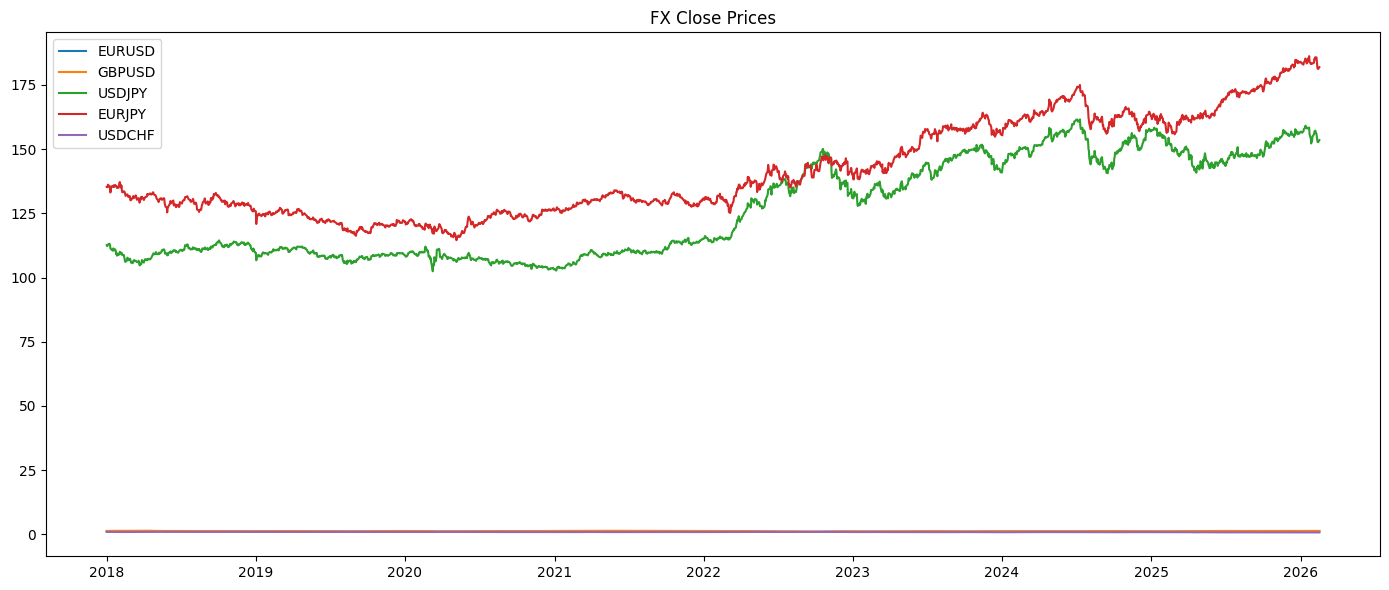

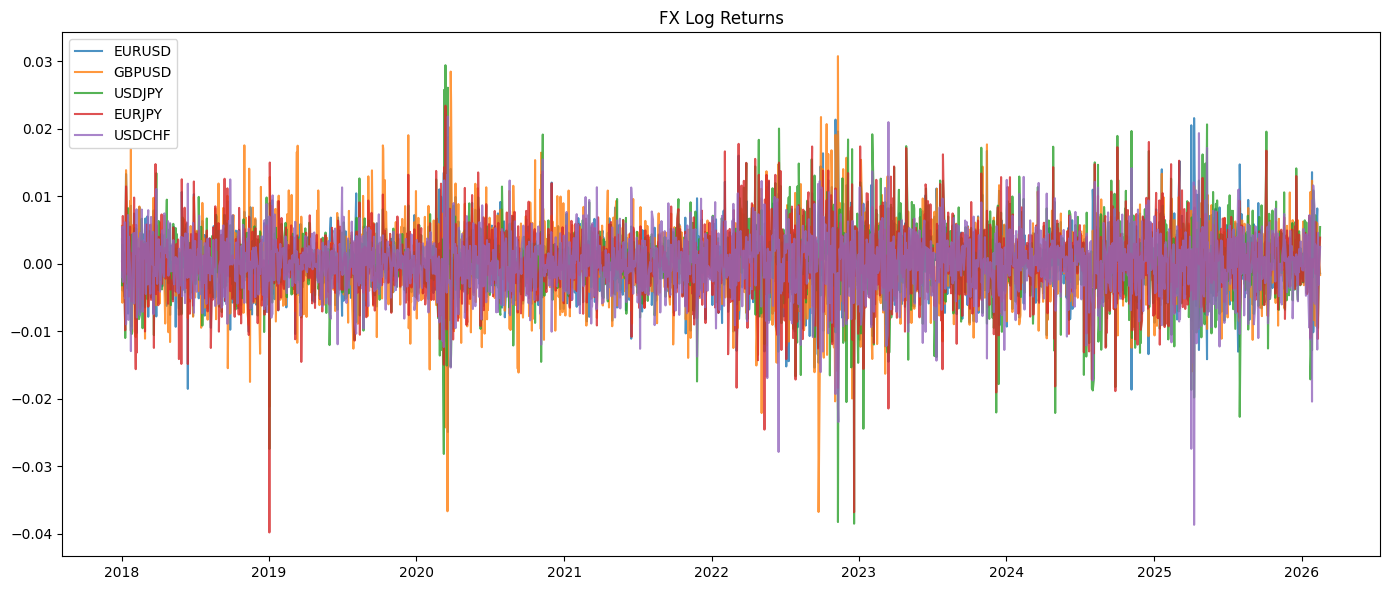

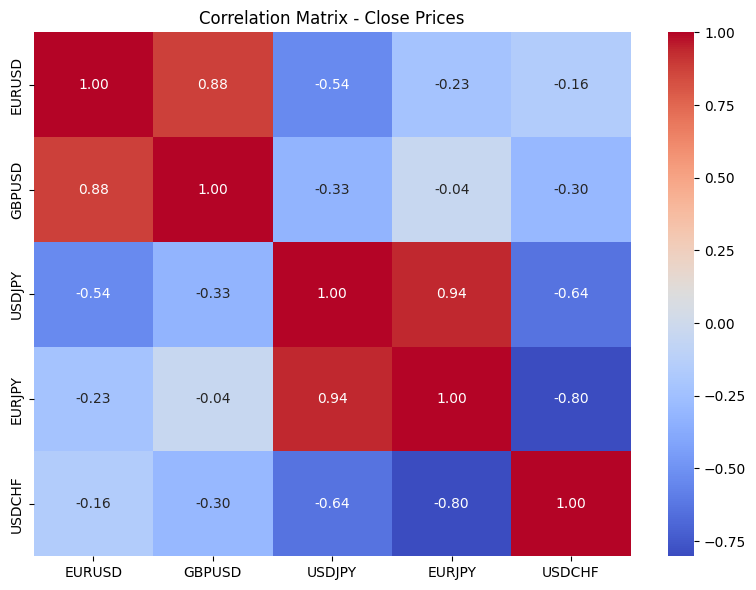

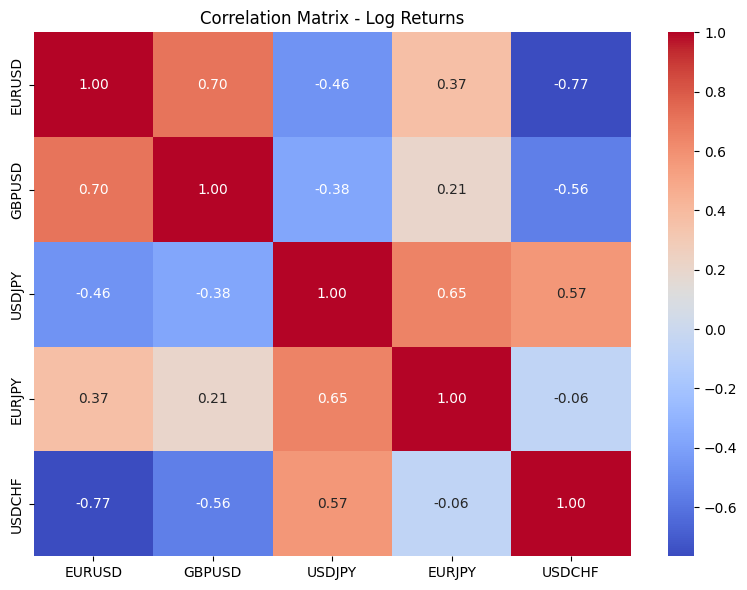


Top correlation relationships:
 Pair1  Pair2  Correlation RelationType         Strength
EURUSD GBPUSD     0.704647     POSITIVE           STRONG
USDJPY EURJPY     0.650104     POSITIVE           STRONG
USDJPY USDCHF     0.570389     POSITIVE           STRONG
EURUSD EURJPY     0.370003      NEUTRAL WEAK_OR_MODERATE
GBPUSD EURJPY     0.206124      NEUTRAL WEAK_OR_MODERATE
EURJPY USDCHF    -0.058298      NEUTRAL WEAK_OR_MODERATE
GBPUSD USDJPY    -0.378526      NEUTRAL WEAK_OR_MODERATE
EURUSD USDJPY    -0.463565      NEUTRAL WEAK_OR_MODERATE
GBPUSD USDCHF    -0.555287     NEGATIVE           STRONG
EURUSD USDCHF    -0.765285     NEGATIVE           STRONG

MODELING: XGBOOST + SIGNAL GENERATION + BACKTESTING

Processing EURUSD ...


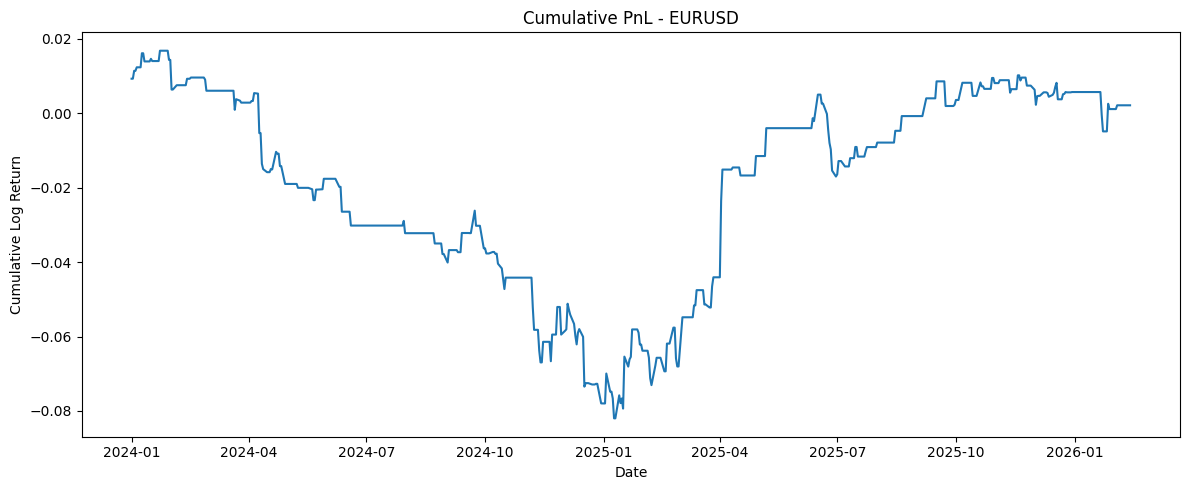

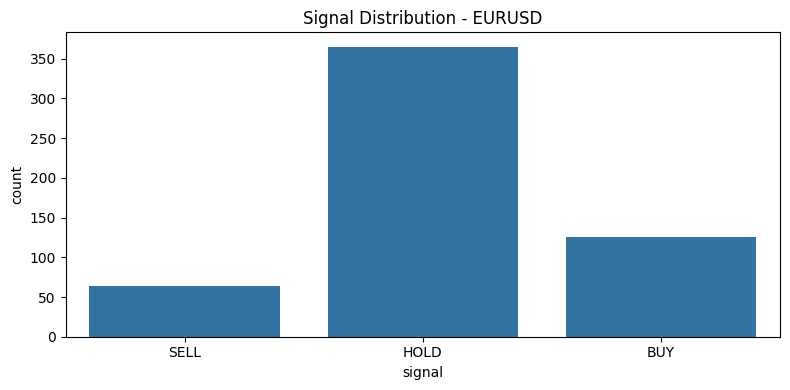

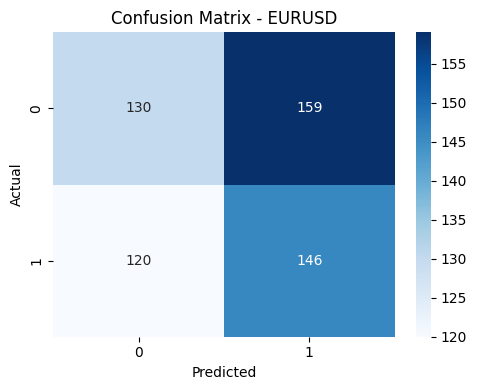

  Done: EURUSD | Acc=0.4973 | F1=0.5114 | Sharpe=0.02

Processing GBPUSD ...


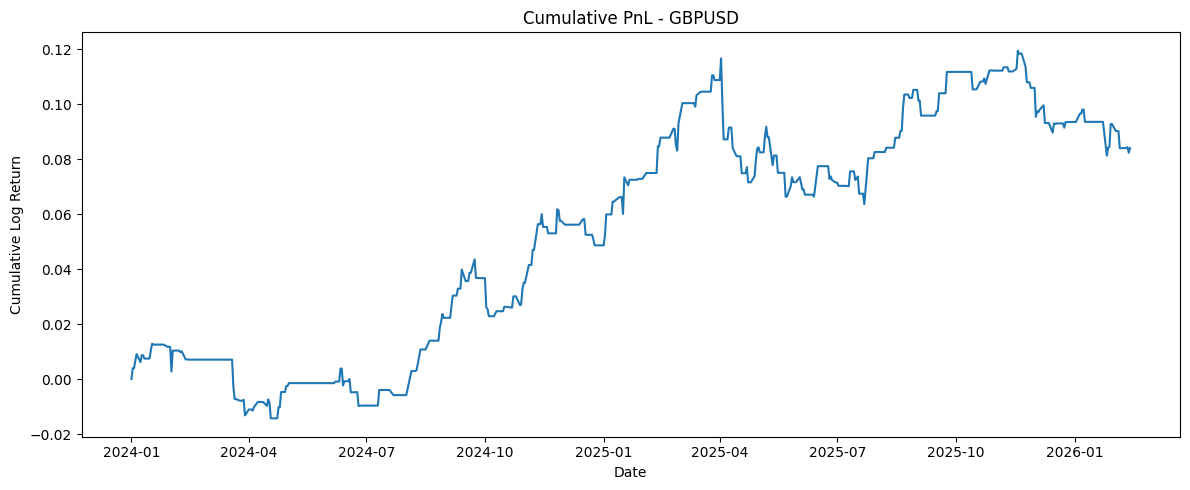

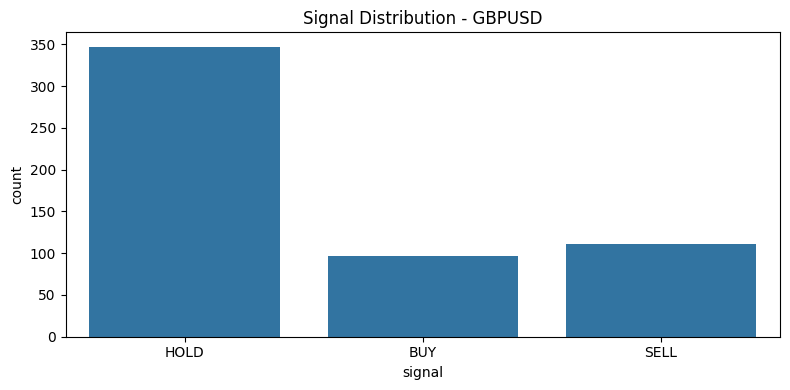

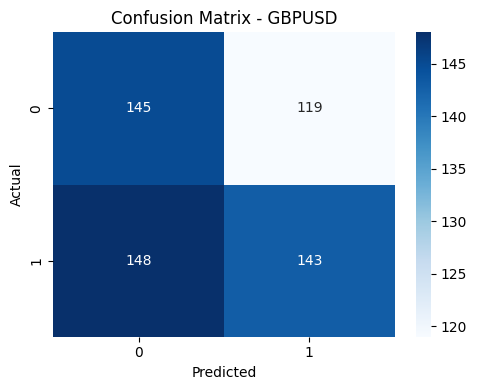

  Done: GBPUSD | Acc=0.5189 | F1=0.5172 | Sharpe=0.84

Processing USDJPY ...


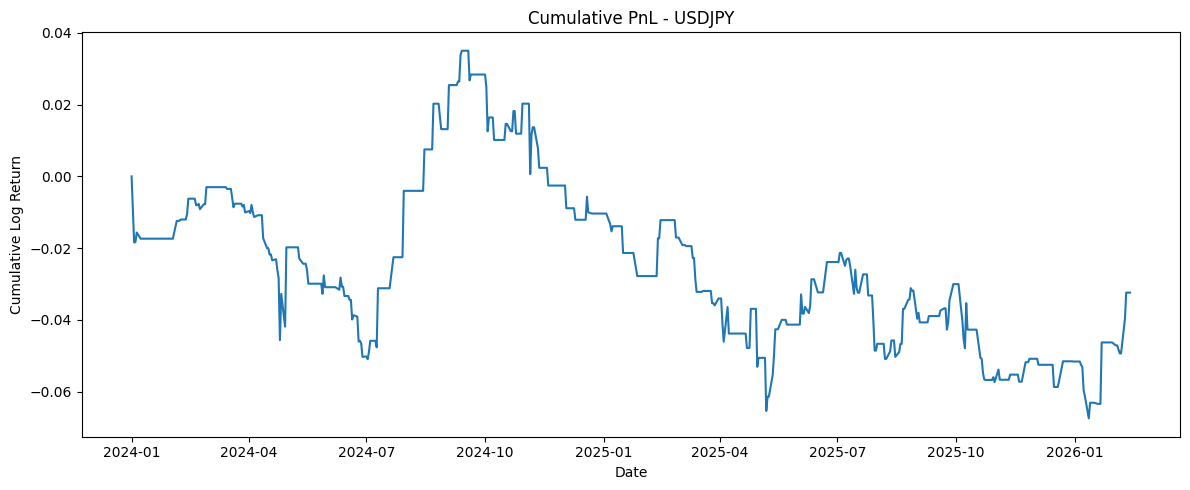

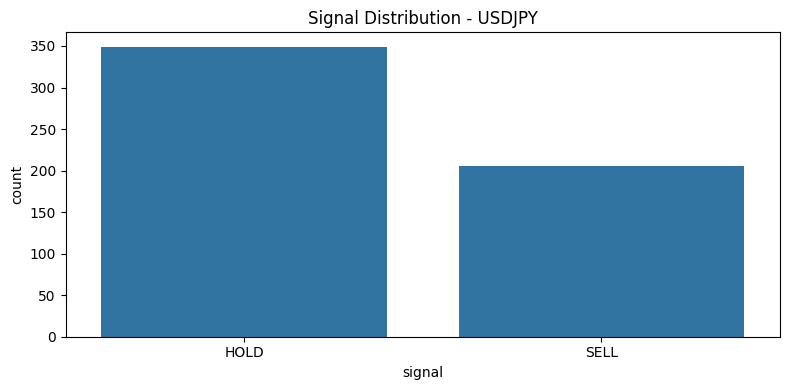

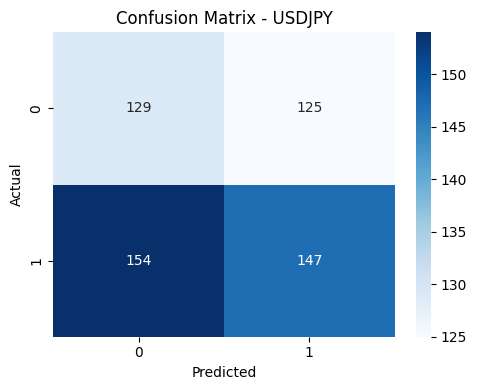

  Done: USDJPY | Acc=0.4973 | F1=0.5131 | Sharpe=-0.25

Processing EURJPY ...


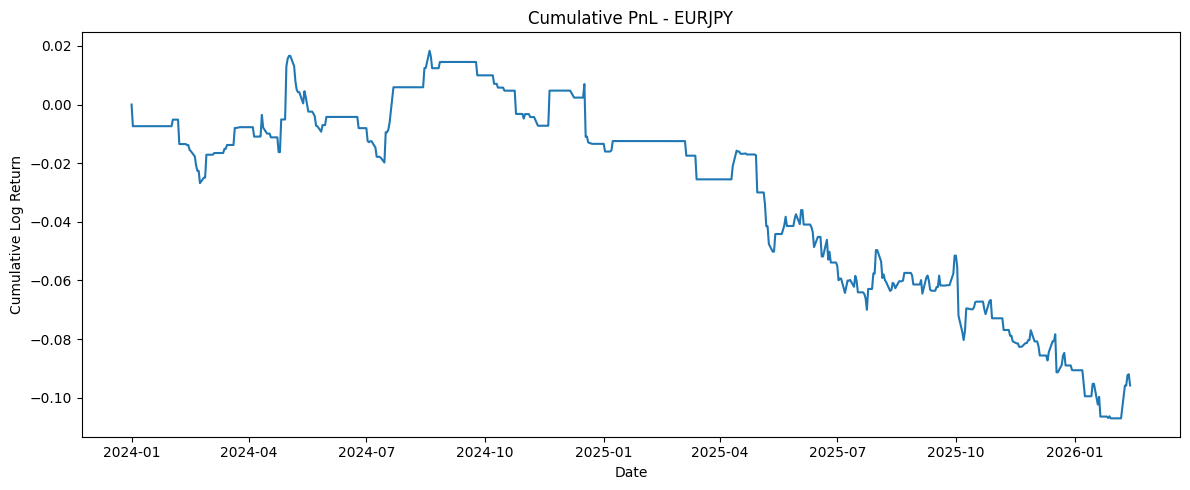

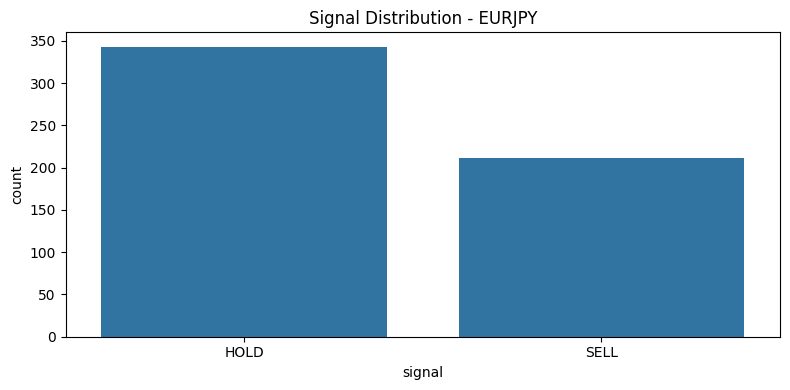

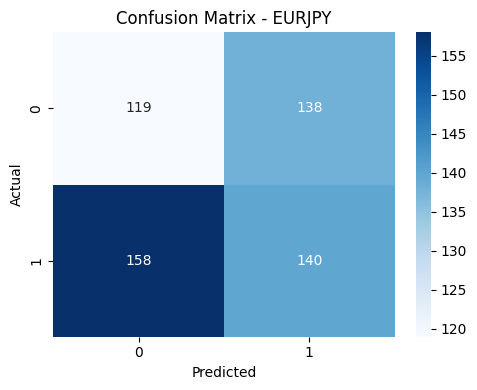

  Done: EURJPY | Acc=0.4667 | F1=0.4861 | Sharpe=-0.98

Processing USDCHF ...


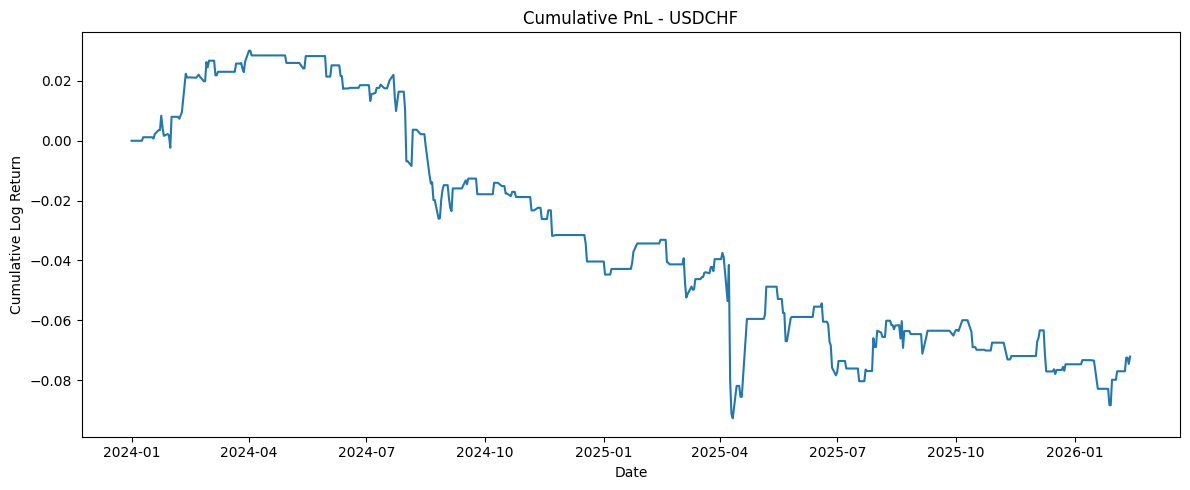

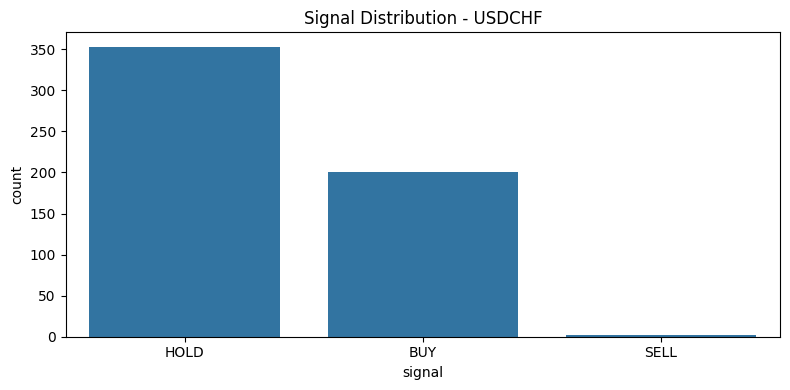

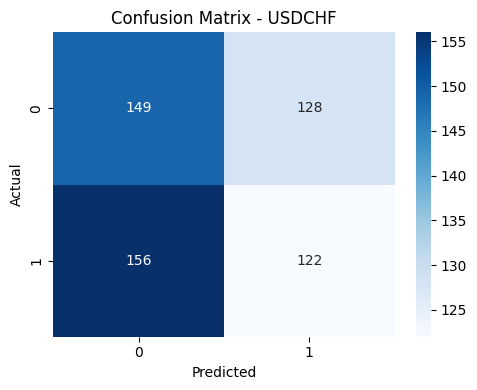

  Done: USDCHF | Acc=0.4883 | F1=0.4621 | Sharpe=-0.63

FINAL RESULTS
  Pair  Train  Test  Reg_MAE  Reg_RMSE   Reg_R2  Cls_Accuracy  Cls_Precision  Cls_Recall  Cls_F1  Sharpe  Total_PnL  WinRate  Max_DD
GBPUSD   1515   555   0.0427    0.0504  -0.6627        0.5189         0.5458      0.4914  0.5172  0.8428     0.0840   0.2144 -0.0530
EURUSD   1515   555   0.0481    0.0561  -0.4865        0.4973         0.4787      0.5489  0.5114  0.0247     0.0022   0.1622 -0.0988
USDJPY   1515   555  20.8377   22.3307 -19.8557        0.4973         0.5404      0.4884  0.5131 -0.2542    -0.0324   0.1658 -0.1025
USDCHF   1515   555   0.0853    0.0950  -3.7012        0.4883         0.4880      0.4388  0.4621 -0.6302    -0.0721   0.1820 -0.1229
EURJPY   1515   555  30.9102   33.7142 -17.8395        0.4667         0.5036      0.4698  0.4861 -0.9841    -0.0959   0.1586 -0.1254

All outputs saved in: ./fx_alphalab_modeling_xgboost
Notebook completed successfully.


In [1]:
# ============================================================
# FX-AlphaLab: From Row Data To Explainable Alpha
# Complete Notebook Version
# Business Understanding + Data Understanding + Modeling
# + Correlation Agent + Backtesting + Explainability
# ============================================================

# ============================================================
# 0. IMPORTS
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import xgboost as xgb
import shap

# ============================================================
# 1. BUSINESS UNDERSTANDING & ANALYTIC APPROACH
# ============================================================

"""
BUSINESS OBJECTIVES (BO)
------------------------
BO1: Enhance estimation performance of trading decisions
BO2: React quickly and effectively to market events
BO3: Achieve superior signal quality and conviction scoring
BO4: Reduce portfolio risk and capture hidden profit opportunities

DATA SCIENCE OBJECTIVES (DSO)
-----------------------------
DSO1: Predict performance of trading decisions
DSO2: Build real-time analysis models
DSO3: Create multi-agent signal aggregation and conviction scoring
DSO4: Build dynamic correlation intelligence and arbitrage detection

ANALYTIC APPROACH
-----------------
To answer these business and data science objectives, this notebook does:

1. Load FX price data for major currency pairs
2. Build predictive features from returns, volatility, momentum, RSI, moving averages
3. Add cross-pair and correlation intelligence features
4. Train:
   - XGBoost Regressor to predict next close price
   - XGBoost Classifier to predict next direction
5. Generate BUY / SELL / HOLD signals
6. Backtest the strategy
7. Evaluate prediction quality and trading performance
8. Use SHAP for explainability

SPECIAL FOCUS
-------------
This notebook includes a Correlation Agent to support:
- cross-market intelligence
- portfolio risk reduction
- hidden opportunity detection
- dynamic correlation analytics
"""

# ============================================================
# 2. CONFIGURATION
# ============================================================
OUT_DIR = "./fx_alphalab_modeling_xgboost"
os.makedirs(OUT_DIR, exist_ok=True)

SPLIT_DATE = "2024-01-01"

PROBA_BUY = 0.60
PROBA_SELL = 0.40
MIN_EXPECTED_LOGRET = 0.0005

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Choose pairs
MAIN_PAIRS = ["EURUSD", "GBPUSD", "USDJPY", "EURJPY", "USDCHF"]

# ============================================================
# 3. DATA ACQUISITION
# ============================================================

print("=" * 80)
print("DATA ACQUISITION")
print("=" * 80)

prices = {}

for pair in MAIN_PAIRS:
    filename = f"{pair}_from_2018.csv"

    if os.path.exists(filename):
        df = pd.read_csv(filename, parse_dates=[0], index_col=0)

        # Standardize column names just in case
        df.columns = [c.strip() for c in df.columns]

        if "Close" not in df.columns:
            raise ValueError(f"Column 'Close' not found in {filename}")

        prices[pair] = df["Close"].astype(float)

        print(
            f"✓ {pair} loaded | {len(df)} rows | "
            f"{df.index.min().date()} -> {df.index.max().date()}"
        )
    else:
        print(f"✗ File not found: {filename}")

if len(prices) == 0:
    raise ValueError("No FX files found. Please place your CSV files in the same folder.")

closes = pd.DataFrame(prices).sort_index()
closes_aligned = closes.dropna().copy()
returns = np.log(closes_aligned / closes_aligned.shift(1)).dropna()

print("\nAligned dataset summary:")
print(f"Number of pairs : {closes_aligned.shape[1]}")
print(f"Number of rows  : {closes_aligned.shape[0]}")
print(f"Date range      : {closes_aligned.index.min().date()} -> {closes_aligned.index.max().date()}")

# Save raw aligned data
closes_aligned.to_csv(os.path.join(OUT_DIR, "aligned_closes.csv"))
returns.to_csv(os.path.join(OUT_DIR, "aligned_returns.csv"))

# ============================================================
# 4. DATA UNDERSTANDING
# ============================================================

print("\n" + "=" * 80)
print("DATA UNDERSTANDING")
print("=" * 80)

print("\nDescriptive statistics on close prices:")
print(closes_aligned.describe().round(4))

print("\nDescriptive statistics on returns:")
print(returns.describe().round(6))

# Missing values
print("\nMissing values in aligned closes:")
print(closes_aligned.isna().sum())

print("\nMissing values in returns:")
print(returns.isna().sum())

# Plot close prices
plt.figure(figsize=(14, 6))
for col in closes_aligned.columns:
    plt.plot(closes_aligned.index, closes_aligned[col], label=col)
plt.title("FX Close Prices")
plt.legend()
plt.tight_layout()
plt.show()

# Plot returns
plt.figure(figsize=(14, 6))
for col in returns.columns:
    plt.plot(returns.index, returns[col], label=col, alpha=0.8)
plt.title("FX Log Returns")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation matrix of closes
corr_close = closes_aligned.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_close, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Close Prices")
plt.tight_layout()
plt.show()

# Correlation matrix of returns
corr_returns = returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_returns, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Log Returns")
plt.tight_layout()
plt.show()

corr_returns.to_csv(os.path.join(OUT_DIR, "correlation_matrix_returns.csv"))

# ============================================================
# 5. CORRELATION AGENT
# ============================================================

def correlation_agent(returns_df, threshold=0.70):
    """
    Detect strong positive and negative correlations between FX pairs.
    Supports DSO4: Dynamic Correlation Intelligence & Arbitrage Detection.
    """
    corr = returns_df.corr()
    records = []

    processed = set()

    for pair1 in corr.columns:
        for pair2 in corr.columns:
            if pair1 == pair2:
                continue

            key = tuple(sorted([pair1, pair2]))
            if key in processed:
                continue

            value = corr.loc[pair1, pair2]

            if value >= threshold:
                rel_type = "POSITIVE"
                strength = "STRONG"
            elif value <= -threshold:
                rel_type = "NEGATIVE"
                strength = "STRONG"
            else:
                rel_type = "NEUTRAL"
                strength = "WEAK_OR_MODERATE"

            records.append({
                "Pair1": pair1,
                "Pair2": pair2,
                "Correlation": value,
                "RelationType": rel_type,
                "Strength": strength
            })

            processed.add(key)

    result = pd.DataFrame(records).sort_values("Correlation", ascending=False)
    return result

correlation_report = correlation_agent(returns, threshold=0.50)
correlation_report.to_csv(os.path.join(OUT_DIR, "correlation_agent_report.csv"), index=False)

print("\nTop correlation relationships:")
print(correlation_report.head(10).to_string(index=False))

# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

def build_features_for_pair(pair: str, closes_df: pd.DataFrame, returns_df: pd.DataFrame):
    """
    Build predictive features for one FX pair.
    Includes:
    - lag returns
    - rolling volatility
    - momentum
    - RSI
    - moving average ratios
    - cross-pair lag features
    - rolling correlation features
    """
    df = pd.DataFrame(index=returns_df.index)

    r = returns_df[pair]
    px = closes_df[pair]

    # --------------------------------------------------------
    # A. RETURN LAGS
    # --------------------------------------------------------
    for lag in [1, 2, 3, 5, 10]:
        df[f"ret_lag_{lag}"] = r.shift(lag)

    # --------------------------------------------------------
    # B. VOLATILITY + MOMENTUM
    # --------------------------------------------------------
    for w in [5, 10, 20, 50]:
        df[f"vol_{w}"] = r.rolling(w).std()
        df[f"ret_mean_{w}"] = r.rolling(w).mean()

    # --------------------------------------------------------
    # C. RSI
    # --------------------------------------------------------
    delta = px.diff()
    up = delta.clip(lower=0).rolling(14).mean()
    down = (-delta).clip(lower=0).rolling(14).mean()
    rs = up / (down + 1e-12)
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # --------------------------------------------------------
    # D. MOVING AVERAGE RATIOS
    # --------------------------------------------------------
    for w in [10, 20, 50]:
        ma = px.rolling(w).mean()
        df[f"ma_ratio_{w}"] = (px / (ma + 1e-12)) - 1.0

    # --------------------------------------------------------
    # E. CROSS-PAIR FEATURES
    # --------------------------------------------------------
    for other in returns_df.columns:
        if other != pair:
            df[f"other_ret_{other}_lag1"] = returns_df[other].shift(1)
            df[f"other_ret_{other}_lag2"] = returns_df[other].shift(2)

    # --------------------------------------------------------
    # F. ROLLING CORRELATION FEATURES
    # --------------------------------------------------------
    for other in returns_df.columns:
        if other != pair:
            df[f"corr_{other}_10"] = r.rolling(10).corr(returns_df[other])
            df[f"corr_{other}_20"] = r.rolling(20).corr(returns_df[other])

    # Benchmark with EURUSD
    if pair != "EURUSD" and "EURUSD" in returns_df.columns:
        df["corr_eurusd_20"] = r.rolling(20).corr(returns_df["EURUSD"])

    return df

# ============================================================
# 7. TARGETS
# ============================================================

def make_targets(pair: str, closes_df: pd.DataFrame):
    """
    y_reg: next close price
    y_cls: next direction (1 if next close > current close, else 0)
    """
    y_reg = closes_df[pair].shift(-1)
    y_cls = (closes_df[pair].shift(-1) > closes_df[pair]).astype(int)
    return y_reg, y_cls

# ============================================================
# 8. METRICS HELPERS
# ============================================================

def compute_regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred))
    }

def compute_classification_metrics(y_true, y_pred):
    return {
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0))
    }

def compute_trading_metrics(pnl):
    pnl = np.array(pnl)
    sharpe = float((np.mean(pnl) / (np.std(pnl) + 1e-12)) * np.sqrt(252))
    total_pnl = float(np.sum(pnl))
    win_rate = float(np.mean(pnl > 0))
    cum_pnl = np.cumsum(pnl)
    max_dd = float(np.min(cum_pnl - np.maximum.accumulate(cum_pnl)))
    return {
        "Sharpe": sharpe,
        "Total_PnL": total_pnl,
        "WinRate": win_rate,
        "Max_DD": max_dd
    }

# ============================================================
# 9. MODELING LOOP
# ============================================================

results = []
feature_importance_summary = []
shap_dict = {}

print("\n" + "=" * 90)
print("MODELING: XGBOOST + SIGNAL GENERATION + BACKTESTING")
print("=" * 90)

for pair in closes_aligned.columns:
    print(f"\nProcessing {pair} ...")

    # Build features and targets
    X = build_features_for_pair(pair, closes_aligned, returns)
    y_reg, y_cls = make_targets(pair, closes_aligned)

    data = X.copy()
    data["y_reg"] = y_reg
    data["y_cls"] = y_cls
    data = data.dropna()

    train = data[data.index < SPLIT_DATE].copy()
    test = data[data.index >= SPLIT_DATE].copy()

    if len(train) < 400 or len(test) < 100:
        print(f"  Warning: not enough data for {pair}")
        continue

    X_train = train.drop(["y_reg", "y_cls"], axis=1)
    X_test = test.drop(["y_reg", "y_cls"], axis=1)

    yreg_train = train["y_reg"]
    yreg_test = test["y_reg"]

    ycls_train = train["y_cls"]
    ycls_test = test["y_cls"]

    # --------------------------------------------------------
    # REGRESSION MODEL
    # --------------------------------------------------------
    reg_model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE
    )

    reg_model.fit(X_train, yreg_train)
    yreg_pred = reg_model.predict(X_test)

    # --------------------------------------------------------
    # CLASSIFICATION MODEL
    # --------------------------------------------------------
    cls_model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )

    cls_model.fit(X_train, ycls_train)
    ycls_pred = cls_model.predict(X_test)
    proba_up = cls_model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # SIGNAL GENERATION
    # DSO3: multi-agent signal aggregation and conviction scoring
    # --------------------------------------------------------
    close_today = closes_aligned.loc[X_test.index, pair].values
    expected_logret = np.log((yreg_pred + 1e-12) / (close_today + 1e-12))

    signal = np.where(
        (proba_up >= PROBA_BUY) & (expected_logret >= MIN_EXPECTED_LOGRET),
        "BUY",
        np.where(
            (proba_up <= PROBA_SELL) & (expected_logret <= -MIN_EXPECTED_LOGRET),
            "SELL",
            "HOLD"
        )
    )

    conviction_score = np.where(
        signal == "BUY",
        proba_up,
        np.where(signal == "SELL", 1 - proba_up, 0.50)
    )

    # --------------------------------------------------------
    # BACKTEST
    # --------------------------------------------------------
    realized_ret = np.log(closes_aligned[pair].shift(-1).loc[X_test.index] / close_today)

    pnl = np.where(
        signal == "BUY",
        realized_ret,
        np.where(signal == "SELL", -realized_ret, 0)
    )

    cum_pnl = np.cumsum(pnl)

    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------
    pred_df = pd.DataFrame({
        "Close_today": close_today,
        "Close_pred": yreg_pred,
        "expected_logret": expected_logret,
        "proba_up": proba_up,
        "signal": signal,
        "conviction_score": conviction_score,
        "realized_ret": realized_ret,
        "pnl": pnl,
        "cum_pnl": cum_pnl
    }, index=X_test.index)

    pred_df.to_csv(os.path.join(OUT_DIR, f"{pair}_predictions_backtest.csv"))

    # --------------------------------------------------------
    # SAVE MODELS
    # --------------------------------------------------------
    joblib.dump(reg_model, os.path.join(OUT_DIR, f"{pair}_xgb_reg.pkl"))
    joblib.dump(cls_model, os.path.join(OUT_DIR, f"{pair}_xgb_cls.pkl"))

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------
    reg_metrics = compute_regression_metrics(yreg_test, yreg_pred)
    cls_metrics = compute_classification_metrics(ycls_test, ycls_pred)
    trd_metrics = compute_trading_metrics(pnl)

    results.append({
        "Pair": pair,
        "Train": len(train),
        "Test": len(test),
        "Reg_MAE": reg_metrics["MAE"],
        "Reg_RMSE": reg_metrics["RMSE"],
        "Reg_R2": reg_metrics["R2"],
        "Cls_Accuracy": cls_metrics["Accuracy"],
        "Cls_Precision": cls_metrics["Precision"],
        "Cls_Recall": cls_metrics["Recall"],
        "Cls_F1": cls_metrics["F1"],
        "Sharpe": trd_metrics["Sharpe"],
        "Total_PnL": trd_metrics["Total_PnL"],
        "WinRate": trd_metrics["WinRate"],
        "Max_DD": trd_metrics["Max_DD"]
    })

    # --------------------------------------------------------
    # FEATURE IMPORTANCE
    # --------------------------------------------------------
    fi = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": cls_model.feature_importances_,
        "Pair": pair
    }).sort_values("Importance", ascending=False)

    feature_importance_summary.append(fi)
    fi.to_csv(os.path.join(OUT_DIR, f"{pair}_feature_importance.csv"), index=False)

    # --------------------------------------------------------
    # SHAP EXPLAINABILITY
    # --------------------------------------------------------
    try:
        explainer = shap.TreeExplainer(cls_model)
        sample_size = min(200, len(X_test))
        X_sample = X_test.iloc[:sample_size]

        shap_values = explainer.shap_values(X_sample)
        shap_dict[pair] = shap_values

        plt.figure()
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title(f"SHAP Summary - {pair}")
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, f"{pair}_shap_summary.png"), dpi=200, bbox_inches="tight")
        plt.close()
    except Exception as e:
        print(f"  SHAP failed for {pair}: {e}")

    # --------------------------------------------------------
    # PLOTS
    # --------------------------------------------------------
    plt.figure(figsize=(12, 5))
    plt.plot(pred_df.index, pred_df["cum_pnl"])
    plt.title(f"Cumulative PnL - {pair}")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Log Return")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_cum_pnl.png"), dpi=200)
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.countplot(x=pred_df["signal"])
    plt.title(f"Signal Distribution - {pair}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_signal_distribution.png"), dpi=200)
    plt.show()

    cm = confusion_matrix(ycls_test, ycls_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {pair}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{pair}_confusion_matrix.png"), dpi=200)
    plt.show()

    print(
        f"  Done: {pair} | "
        f"Acc={cls_metrics['Accuracy']:.4f} | "
        f"F1={cls_metrics['F1']:.4f} | "
        f"Sharpe={trd_metrics['Sharpe']:.2f}"
    )

# ============================================================
# 10. GLOBAL SUMMARY
# ============================================================

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values("Sharpe", ascending=False)

summary_path = os.path.join(OUT_DIR, "xgboost_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 90)
print("FINAL RESULTS")
print("=" * 90)

if len(summary_df) > 0:
    print(summary_df.round(4).to_string(index=False))
else:
    print("No valid model results available.")

# Save all feature importances
if len(feature_importance_summary) > 0:
    all_fi = pd.concat(feature_importance_summary, axis=0)
    all_fi.to_csv(os.path.join(OUT_DIR, "all_feature_importance.csv"), index=False)

# ============================================================
# 11. BUSINESS INTERPRETATION
# ============================================================

"""
HOW THIS NOTEBOOK ANSWERS THE PROJECT OBJECTIVES
------------------------------------------------

BO1 - Enhance estimation performance of trading decisions
    -> Done with XGBoost regression + classification
    -> We predict price and direction

BO2 - React quickly and effectively to market events
    -> Done with rolling features, short-term lags, real-time style signals

BO3 - Achieve superior signal quality and conviction scoring
    -> Done with BUY / SELL / HOLD rules
    -> Done with probability-based conviction_score

BO4 - Reduce portfolio risk and capture hidden profit opportunities
    -> Done with Correlation Agent
    -> Done with cross-pair features and rolling correlation features

DSO1 - Predict performance of trading decisions
    -> Done through prediction + evaluation metrics

DSO2 - Real-time analysis models
    -> The model uses recent rolling and lagged data to simulate real-time analysis

DSO3 - Multi-agent signal aggregation and conviction scoring
    -> Regression model + classification model + threshold rules = signal engine

DSO4 - Dynamic Correlation Intelligence & Arbitrage Detection
    -> Done with Correlation Agent and dynamic correlation features
"""

print(f"\nAll outputs saved in: {OUT_DIR}")
print("Notebook completed successfully.")